# 02 — Elo Rating Model

Build and run Elo ratings through all competitive matches. Produces a time-series of ratings per team.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.elo import EloModel

%matplotlib inline

In [2]:
df = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,result,home_fifa_rank,away_fifa_rank,home_fifa_points,away_fifa_points
0,1980-02-06,England,Republic of Ireland,2.0,0.0,UEFA Euro qualification,London,England,False,1980,home,5.0,6.0,55.0,54.0
1,1980-02-24,Vanuatu,Papua New Guinea,3.0,4.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,159.0,179.0,0.0,1.0
2,1980-02-24,New Caledonia,Australia,0.0,8.0,Oceania Nations Cup,Nouméa,New Caledonia,False,1980,away,186.0,45.0,119.0,29.0
3,1980-02-25,New Zealand,Tahiti,1.0,3.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,70.0,123.0,22.0,5.0
4,1980-02-25,Fiji,Solomon Islands,3.0,1.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,home,106.0,136.0,9.0,2.0


## Fit Elo ratings

In [3]:
model = EloModel(k=32, home_advantage=100, initial_rating=1500, regression_factor=0.0)
df = model.fit(df)   # adds 'home_elo_pre', 'away_elo_pre', 'home_win_prob' columns
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,result,home_fifa_rank,away_fifa_rank,home_fifa_points,away_fifa_points,home_elo_pre,away_elo_pre,home_win_prob,k_adjusted
0,1980-02-06,England,Republic of Ireland,2.0,0.0,UEFA Euro qualification,London,England,False,1980,home,5.0,6.0,55.0,54.0,1500.0,1500.0,0.640065,64.000000
1,1980-02-24,Vanuatu,Papua New Guinea,3.0,4.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,159.0,179.0,0.0,1.0,1500.0,1500.0,0.500000,15.824176
2,1980-02-24,New Caledonia,Australia,0.0,8.0,Oceania Nations Cup,Nouméa,New Caledonia,False,1980,away,186.0,45.0,119.0,29.0,1500.0,1500.0,0.640065,45.098901
3,1980-02-25,New Zealand,Tahiti,1.0,3.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,70.0,123.0,22.0,5.0,1500.0,1500.0,0.500000,23.736264
4,1980-02-25,Fiji,Solomon Islands,3.0,1.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,home,106.0,136.0,9.0,2.0,1500.0,1500.0,0.500000,23.736264


## Current ratings

In [4]:
ratings = model.current_ratings()
ratings.sort_values('elo', ascending=False).head(20)

,team,elo
0,Spain,2079.637021
1,Argentina,2036.745678
2,France,2002.616477
3,England,1973.882786
4,Japan,1948.322313
5,Mexico,1916.975678
6,Morocco,1916.582936
7,Brazil,1915.766973
8,Iran,1912.169158
9,South Korea,1900.632522


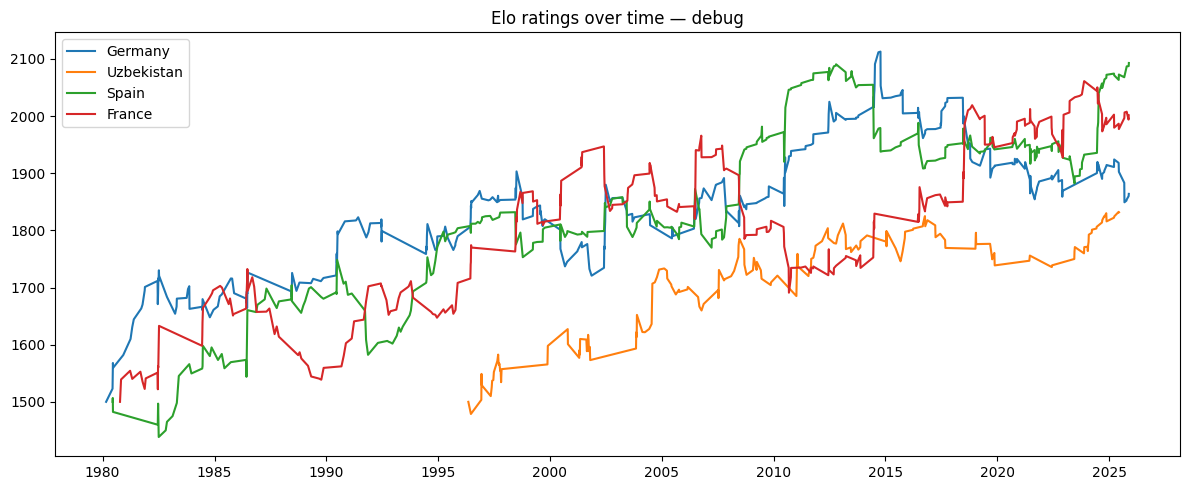

In [5]:
# Germany vs Uzbekistan rating history
debug_teams = ['Germany', 'Uzbekistan', 'Spain', 'France']
debug_history = model.rating_history(debug_teams)

fig, ax = plt.subplots(figsize=(12, 5))
for team in debug_teams:
    h = debug_history[debug_history['team'] == team]
    ax.plot(h['date'], h['elo'], label=team)
ax.legend()
ax.set_title('Elo ratings over time — debug')
plt.tight_layout()

In [6]:
# Germany's last 10 matches
cols = ['date','home_team','away_team','home_score','away_score','tournament','home_win_prob','k_adjusted']
df[((df['home_team'] == 'Germany') | (df['away_team'] == 'Germany'))].tail(10)[cols]

,date,home_team,away_team,home_score,away_score,tournament,home_win_prob,k_adjusted
20488,2025-03-20,Italy,Germany,1.0,2.0,UEFA Nations League,0.550963,24.0
20559,2025-03-23,Germany,Italy,3.0,3.0,UEFA Nations League,0.750066,24.0
20640,2025-06-04,Germany,Portugal,1.0,2.0,UEFA Nations League,0.649416,24.0
20688,2025-06-08,Germany,France,0.0,2.0,UEFA Nations League,0.536231,36.0
20793,2025-09-04,Slovakia,Germany,2.0,0.0,FIFA World Cup qualification,0.290464,48.0
20839,2025-09-07,Germany,Northern Ireland,3.0,1.0,FIFA World Cup qualification,0.939074,48.0
20953,2025-10-10,Germany,Luxembourg,4.0,0.0,FIFA World Cup qualification,0.970102,60.0
20992,2025-10-13,Northern Ireland,Germany,0.0,1.0,FIFA World Cup qualification,0.189752,32.0
21055,2025-11-14,Luxembourg,Germany,0.0,2.0,FIFA World Cup qualification,0.082417,48.0
21083,2025-11-17,Germany,Slovakia,6.0,0.0,FIFA World Cup qualification,0.859230,64.0


In [7]:
# Uzbekistan's last 10 matches
df[((df['home_team'] == 'Uzbekistan') | (df['away_team'] == 'Uzbekistan'))].tail(10)[cols]

,date,home_team,away_team,home_score,away_score,tournament,home_win_prob,k_adjusted
19949,2024-09-05,Uzbekistan,North Korea,1.0,0.0,FIFA World Cup qualification,0.856213,29.538462
20094,2024-09-10,Kyrgyzstan,Uzbekistan,2.0,3.0,FIFA World Cup qualification,0.218618,29.538462
20129,2024-10-10,Uzbekistan,Iran,0.0,0.0,FIFA World Cup qualification,0.525214,29.538462
20257,2024-10-15,Uzbekistan,United Arab Emirates,1.0,0.0,FIFA World Cup qualification,0.786927,29.538462
20293,2024-11-14,Qatar,Uzbekistan,3.0,2.0,FIFA World Cup qualification,0.516229,29.538462
20421,2024-11-19,North Korea,Uzbekistan,0.0,1.0,FIFA World Cup qualification,0.217780,29.538462
20502,2025-03-20,Uzbekistan,Kyrgyzstan,1.0,0.0,FIFA World Cup qualification,0.923551,29.538462
20595,2025-03-25,Iran,Uzbekistan,2.0,2.0,FIFA World Cup qualification,0.772378,29.538462
20653,2025-06-05,United Arab Emirates,Uzbekistan,0.0,0.0,FIFA World Cup qualification,0.471641,29.538462
20716,2025-06-10,Uzbekistan,Qatar,3.0,0.0,FIFA World Cup qualification,0.776652,51.692308


In [8]:
# Brazil's last 10 matches
df[((df['home_team'] == 'Brazil') | (df['away_team'] == 'Brazil'))].tail(10)[cols].to_clipboard()

## Rating history — top nations

In [9]:
# Save enriched match data
df.to_csv('../data/processed/matches_with_elo.csv', index=False)
print('Saved.')

Saved.
